# Multi-segment Eval Comparison

This notebook compares a single evaluation episode by overlaying:
- ground-truth labeled segments from the dataset
- Gemini predicted intervals from `eval_results_multiseg/*.jsonl` or `results/result_multiseg_*.json`
- the episode angular gaze-speed curve
- optional representative-frame markers from `results/refined_result_multiseg_*.json`
- GT and predicted video clips for debugging

The interactive browser at the bottom lets you click through episodes. When a refinement file is available, it also shows interval midpoint frames and minimum gaze-speed frames on top of the same plot.


In [43]:
from pathlib import Path
import json
import re
from collections import OrderedDict

import shutil
import subprocess
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import Video, clear_output, display
from scipy.signal import savgol_filter

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)

DATASET_DIR = Path("dataset")
PREDICTION_SOURCE = Path("eval_results_multiseg/multiseg_gemini-3.1-flash-lite-preview_fps4_max2_results.jsonl")
EPISODE_NAME = "2f_store_juheon_setup_single_object_pick_place_10"
VIDEO_FPS_FALLBACK = 15.0
FFMPEG_BIN = shutil.which("ffmpeg") or "ffmpeg"

CLIP_PADDING_SEC = 0.4
CLIP_OUTPUT_DIR = Path("debug/generated_multiseg_clips")
DISPLAY_GT_CLIPS = True
DISPLAY_PRED_CLIPS = True

GT_COLORS = {
    1: "#2563eb",
    2: "#ef4444",
    3: "#10b981",
}

PRED_COLORS = {
    1: "#1d4ed8",
    2: "#b91c1c",
    3: "#047857",
}

RESULT_METRIC_KEYS = [
    "pred_interval_count",
    "gt_interval_count",
    "count_error",
    "abs_count_error",
    "matched_count",
    "segment_precision",
    "segment_recall",
    "segment_f1",
    "exact_count_match",
    "all_gt_matched",
    "all_pred_matched",
    "frame_iou",
    "gt_frame_coverage",
    "pred_frame_precision",
    "pred_midpoint_hit_count",
    "pred_midpoint_hit_rate",
    "pred_midpoint_nearest_dist_mean",
    "mean_matched_iou",
    "mean_matched_midpoint_error_sec",
    "best_pred_iou_mean",
    "best_gt_iou_mean",
]


In [44]:
def compute_angular_velocity(pitch_yaw: np.ndarray, fps: float, savgol_window: int = 11, savgol_poly: int = 2) -> np.ndarray:
    pitch = pitch_yaw[:, 0]
    yaw = pitch_yaw[:, 3]

    total_frames = len(pitch)
    if total_frames <= 1 or fps <= 0:
        return np.zeros(total_frames, dtype=np.float64)

    if total_frames < savgol_window:
        savgol_window = total_frames if total_frames % 2 == 1 else total_frames - 1
    savgol_window = max(savgol_window, 3)

    if savgol_poly >= savgol_window:
        savgol_poly = savgol_window - 1

    pitch_s = savgol_filter(pitch, savgol_window, savgol_poly)
    yaw_s = savgol_filter(yaw, savgol_window, savgol_poly)

    x = np.cos(pitch_s) * np.cos(yaw_s)
    y = np.cos(pitch_s) * np.sin(yaw_s)
    z = np.sin(pitch_s)

    step_dot = np.clip(
        x[:-1] * x[1:] + y[:-1] * y[1:] + z[:-1] * z[1:],
        -1.0,
        1.0,
    )
    step_velocity = np.arccos(step_dot) * fps

    angular_velocity = np.zeros(total_frames, dtype=np.float64)
    angular_velocity[0] = step_velocity[0]
    angular_velocity[-1] = step_velocity[-1]

    if total_frames > 2:
        center_dot = np.clip(
            x[:-2] * x[2:] + y[:-2] * y[2:] + z[:-2] * z[2:],
            -1.0,
            1.0,
        )
        angular_velocity[1:-1] = np.arccos(center_dot) * (fps / 2.0)

    return np.rad2deg(angular_velocity)


def _coerce_int(value):
    try:
        return int(value)
    except (TypeError, ValueError):
        return None


def extract_segments(frame_indices: np.ndarray) -> list[tuple[int, int]]:
    if len(frame_indices) == 0:
        return []

    frame_indices = [int(idx) for idx in frame_indices]
    segments = []
    start = frame_indices[0]
    prev = frame_indices[0]

    for current in frame_indices[1:]:
        if current != prev + 1:
            segments.append((start, prev))
            start = current
        prev = current

    segments.append((start, prev))
    return segments


def extract_segments_from_labels(labels: np.ndarray) -> list[dict]:
    labels = labels.astype(np.int8)
    if labels.size == 0:
        return []

    diffs = np.diff(labels)
    starts = list(np.where(diffs == 1)[0] + 1)
    ends = list(np.where(diffs == -1)[0] + 1)
    if labels[0] == 1:
        starts = [0] + starts
    if labels[-1] == 1:
        ends = ends + [len(labels)]

    segments = []
    for start, end_exclusive in zip(starts, ends):
        end = int(end_exclusive - 1)
        if end >= start:
            segments.append({"start_frame": int(start), "end_frame": end})
    return segments


def load_ordered_segments(episode_dir: Path, labels: np.ndarray | None) -> tuple[list[dict], float | None]:
    ann_path = episode_dir / "annotations.json"
    if ann_path.exists():
        ann_data = json.loads(ann_path.read_text())
        fps = ann_data.get("fps")
        try:
            fps = float(fps)
        except (TypeError, ValueError):
            fps = None

        annotations = ann_data.get("annotations", [])
        if isinstance(annotations, list):
            segments = []
            for ann in annotations:
                if not isinstance(ann, dict):
                    continue
                kind = ann.get("kind")
                if kind not in (None, "label"):
                    continue
                start = _coerce_int(ann.get("start_frame", ann.get("start")))
                end = _coerce_int(ann.get("end_frame", ann.get("end")))
                if start is None or end is None:
                    continue
                if end < start:
                    start, end = end, start
                segments.append({"start_frame": start, "end_frame": end})
            if segments:
                return sorted(segments, key=lambda item: (item["start_frame"], item["end_frame"])), fps

    seg_path = episode_dir / "segments.json"
    if seg_path.exists():
        seg_data = json.loads(seg_path.read_text())
        raw_segments = seg_data.get("segments", [])
        if isinstance(raw_segments, list):
            segments = []
            for seg in raw_segments:
                if not isinstance(seg, dict):
                    continue
                start = _coerce_int(seg.get("start_frame", seg.get("start")))
                end = _coerce_int(seg.get("end_frame", seg.get("end")))
                if start is None or end is None:
                    continue
                if end < start:
                    start, end = end, start
                segments.append({"start_frame": start, "end_frame": end})
            if segments:
                return sorted(segments, key=lambda item: (item["start_frame"], item["end_frame"])), None

    if labels is not None:
        return extract_segments_from_labels(labels), None
    return [], None


def load_episode_data(episode_dir: Path, fps_fallback: float = VIDEO_FPS_FALLBACK) -> dict:
    if not episode_dir.exists():
        raise FileNotFoundError(f"Episode directory not found: {episode_dir}")

    labels_path = episode_dir / "labels.npy"
    gaze_path = episode_dir / "gaze.json"
    video_path = episode_dir / "video.mp4"

    labels = np.load(labels_path).astype(np.int8) if labels_path.exists() else None
    gaze_frames = json.loads(gaze_path.read_text()).get("frames", []) if gaze_path.exists() else []

    ordered_segments, ann_fps = load_ordered_segments(episode_dir, labels)
    fps = ann_fps or fps_fallback

    if labels is None:
        total_frames = len(gaze_frames)
        if total_frames <= 0 and ordered_segments:
            total_frames = max(seg["end_frame"] for seg in ordered_segments) + 1
        labels = np.zeros(total_frames, dtype=np.int8)
        for seg in ordered_segments:
            labels[seg["start_frame"]:seg["end_frame"] + 1] = 1
    else:
        total_frames = len(labels)

    if not ordered_segments:
        ordered_segments = extract_segments_from_labels(labels)

    ordered_segments = sorted(ordered_segments, key=lambda item: (item["start_frame"], item["end_frame"]))
    gt_segments = []
    ordered_label_signal = np.zeros(total_frames, dtype=np.int8)
    for idx, seg in enumerate(ordered_segments):
        start = int(seg["start_frame"])
        end = int(seg["end_frame"])
        ordered_label_signal[start:end + 1] = idx + 1
        mid_frame = int(round((start + end) / 2))
        gt_segments.append(
            {
                "segment_idx": idx,
                "label_id": idx + 1,
                "start_frame": start,
                "end_frame": end,
                "start_sec": round(start / fps, 4),
                "end_sec": round(end / fps, 4),
                "mid_frame": mid_frame,
                "mid_sec": round(mid_frame / fps, 4),
                "duration_frames": end - start + 1,
                "duration_sec": round((end - start + 1) / fps, 4),
            }
        )

    if gaze_frames:
        pitch_yaw = np.array(
            [
                [
                    frame["pitch"],
                    frame["pitch_lower"],
                    frame["pitch_upper"],
                    frame["yaw"],
                    frame["yaw_lower"],
                    frame["yaw_upper"],
                ]
                for frame in gaze_frames[:total_frames]
            ],
            dtype=np.float64,
        )
        angular_speed = compute_angular_velocity(pitch_yaw, fps=fps)
    else:
        angular_speed = np.full(total_frames, np.nan)

    frame_times = np.arange(total_frames, dtype=np.float64) / fps if fps > 0 else np.arange(total_frames, dtype=np.float64)
    return {
        "episode": episode_dir.name,
        "fps": fps,
        "total_frames": total_frames,
        "duration_sec": total_frames / fps if fps > 0 else 0.0,
        "labels": labels,
        "ordered_label_signal": ordered_label_signal,
        "segments": gt_segments,
        "frame_times": frame_times,
        "frame_step_sec": 1.0 / fps if fps > 0 else 1.0,
        "angular_speed_deg_s": angular_speed,
        "video_path": video_path,
    }


def build_prediction_intervals_from_pair_lists(frame_pairs, sec_pairs=None):
    intervals = []
    sec_pairs = sec_pairs or []
    for idx, frame_pair in enumerate(frame_pairs):
        if not isinstance(frame_pair, (list, tuple)) or len(frame_pair) < 2:
            continue
        start_frame = int(frame_pair[0])
        end_frame = int(frame_pair[1])
        if end_frame < start_frame:
            start_frame, end_frame = end_frame, start_frame

        start_sec = None
        end_sec = None
        if idx < len(sec_pairs):
            sec_pair = sec_pairs[idx]
            if isinstance(sec_pair, (list, tuple)) and len(sec_pair) >= 2:
                try:
                    start_sec = float(sec_pair[0])
                    end_sec = float(sec_pair[1])
                except (TypeError, ValueError):
                    start_sec = None
                    end_sec = None

        mid_frame = int(round((start_frame + end_frame) / 2))
        interval = {
            "pred_idx": idx,
            "start_frame": start_frame,
            "end_frame": end_frame,
            "mid_frame": mid_frame,
            "duration_frames": end_frame - start_frame + 1,
        }
        if start_sec is not None and end_sec is not None:
            interval.update(
                {
                    "start_sec": start_sec,
                    "end_sec": end_sec,
                    "mid_sec": round((start_sec + end_sec) / 2.0, 4),
                    "duration_sec": round(end_sec - start_sec, 4),
                }
            )
        intervals.append(interval)
    return intervals


def load_prediction_records(source_path: Path) -> list[dict]:
    if not source_path.exists():
        raise FileNotFoundError(f"Prediction source not found: {source_path}")

    if source_path.suffix == ".jsonl":
        with open(source_path) as f:
            return [json.loads(line) for line in f if line.strip()]

    if source_path.suffix == ".json":
        with open(source_path) as f:
            payload = json.load(f)

        if isinstance(payload, dict) and isinstance(payload.get("episodes"), list):
            records = []
            for item in payload["episodes"]:
                metrics = {key: item.get(key) for key in RESULT_METRIC_KEYS if key in item}
                records.append(
                    {
                        "episode": item["episode"],
                        "prediction": {
                            "reasoning": item.get("prediction_reasoning", ""),
                            "intervals": build_prediction_intervals_from_pair_lists(
                                item.get("predicted_intervals_frames", []),
                                item.get("predicted_intervals_sec", []),
                            ),
                        },
                        "metrics": metrics,
                        "matches": item.get("matches", []),
                    }
                )
            return records

    raise ValueError(f"Unsupported prediction source format: {source_path}")


def normalize_prediction_intervals(intervals: list[dict], fps: float) -> list[dict]:
    normalized = []
    for idx, interval in enumerate(intervals):
        start_frame = int(interval["start_frame"])
        end_frame = int(interval["end_frame"])
        if end_frame < start_frame:
            start_frame, end_frame = end_frame, start_frame

        pred_idx = int(interval.get("pred_idx", idx))
        start_sec = interval.get("start_sec")
        end_sec = interval.get("end_sec")
        if start_sec is None:
            start_sec = round(start_frame / fps, 4)
        else:
            start_sec = float(start_sec)
        if end_sec is None:
            end_sec = round(end_frame / fps, 4)
        else:
            end_sec = float(end_sec)

        mid_frame = int(round((start_frame + end_frame) / 2))
        normalized.append(
            {
                "pred_idx": pred_idx,
                "start_frame": start_frame,
                "end_frame": end_frame,
                "start_sec": start_sec,
                "end_sec": end_sec,
                "mid_frame": mid_frame,
                "mid_sec": round((start_sec + end_sec) / 2.0, 4),
                "duration_frames": end_frame - start_frame + 1,
                "duration_sec": round(end_sec - start_sec, 4),
            }
        )

    return sorted(normalized, key=lambda item: (item["pred_idx"], item["start_frame"], item["end_frame"]))


def build_interval_signal(total_frames: int, intervals: list[dict], id_key: str) -> np.ndarray:
    signal = np.zeros(total_frames, dtype=np.int8)
    if total_frames <= 0:
        return signal

    for fallback_idx, interval in enumerate(intervals):
        label_id = int(interval.get(id_key, fallback_idx)) + 1
        start_frame = max(0, min(total_frames - 1, int(interval["start_frame"])))
        end_frame = max(0, min(total_frames - 1, int(interval["end_frame"])))
        if end_frame >= start_frame:
            signal[start_frame:end_frame + 1] = label_id
    return signal


def sanitize_filename(text: str) -> str:
    return re.sub(r"[^A-Za-z0-9._-]+", "_", text)


def extract_video_subclip(video_path: Path, start_sec: float, end_sec: float, output_path: Path, overlay_text: str | None = None) -> Path:
    if end_sec <= start_sec:
        end_sec = start_sec + 0.1

    output_path.parent.mkdir(parents=True, exist_ok=True)
    cmd = [
        FFMPEG_BIN,
        "-y",
        "-ss",
        f"{start_sec:.4f}",
        "-to",
        f"{end_sec:.4f}",
        "-i",
        str(video_path),
        "-an",
        "-c:v",
        "libx264",
        "-pix_fmt",
        "yuv420p",
        str(output_path),
    ]
    try:
        subprocess.run(cmd, check=True, capture_output=True)
    except FileNotFoundError as exc:
        raise RuntimeError("ffmpeg binary not found") from exc
    except subprocess.CalledProcessError as exc:
        stderr = exc.stderr.decode("utf-8", errors="ignore")
        raise RuntimeError(f"ffmpeg failed for {output_path}: {stderr}") from exc
    return output_path


def build_clip_specs(episode_data: dict, prediction_intervals: list[dict], include_gt: bool = DISPLAY_GT_CLIPS, include_pred: bool = DISPLAY_PRED_CLIPS) -> pd.DataFrame:
    clip_rows = []
    video_path = episode_data["video_path"]
    total_duration = episode_data["duration_sec"]
    episode_dir = CLIP_OUTPUT_DIR / sanitize_filename(episode_data["episode"])

    if include_gt:
        for segment in episode_data["segments"]:
            label_id = int(segment["label_id"])
            clip_rows.append(
                {
                    "kind": "gt",
                    "label_id": label_id,
                    "start_sec": float(segment["start_sec"]),
                    "end_sec": float(segment["end_sec"] + episode_data["frame_step_sec"]),
                    "start_frame": int(segment["start_frame"]),
                    "end_frame": int(segment["end_frame"]),
                    "duration_sec": float(segment["duration_sec"]),
                    "video_path": video_path,
                    "overlay_text": f"GT {label_id}",
                    "clip_path": episode_dir / f"gt_label_{label_id}.mp4",
                }
            )

    if include_pred:
        for interval in prediction_intervals:
            label_id = int(interval["pred_idx"]) + 1
            clip_rows.append(
                {
                    "kind": "pred",
                    "label_id": label_id,
                    "start_sec": float(interval["start_sec"]),
                    "end_sec": float(interval["end_sec"] + episode_data["frame_step_sec"]),
                    "start_frame": int(interval["start_frame"]),
                    "end_frame": int(interval["end_frame"]),
                    "duration_sec": float(interval["duration_sec"]),
                    "video_path": video_path,
                    "overlay_text": f"Pred {label_id}",
                    "clip_path": episode_dir / f"pred_label_{label_id}.mp4",
                }
            )

    for row in clip_rows:
        row["clip_start_sec"] = max(0.0, row["start_sec"] - CLIP_PADDING_SEC)
        row["clip_end_sec"] = min(total_duration, row["end_sec"] + CLIP_PADDING_SEC)
        extract_video_subclip(
            row["video_path"],
            row["clip_start_sec"],
            row["clip_end_sec"],
            row["clip_path"],
            overlay_text=row["overlay_text"],
        )

    return pd.DataFrame(clip_rows)


In [45]:
prediction_records = load_prediction_records(PREDICTION_SOURCE)
available_episodes = sorted(record["episode"] for record in prediction_records)
print(f"Loaded {len(prediction_records)} prediction record(s) from {PREDICTION_SOURCE}")
print("Available episodes:")
for episode in available_episodes:
    print("  -", episode)

selected_record = next((record for record in prediction_records if record["episode"] == EPISODE_NAME), None)
if selected_record is None:
    raise ValueError(f"Episode not found in prediction source: {EPISODE_NAME}")

episode_data = load_episode_data(DATASET_DIR / EPISODE_NAME)
prediction = selected_record.get("prediction") or {"reasoning": "", "intervals": []}
prediction_intervals = normalize_prediction_intervals(prediction.get("intervals", []), episode_data["fps"])
predicted_signal = build_interval_signal(episode_data["total_frames"], prediction_intervals, id_key="pred_idx")

metrics = selected_record.get("metrics") or {}
matches = selected_record.get("matches") or []
reasoning = prediction.get("reasoning", "")

print(f"Selected episode: {EPISODE_NAME}")
print(f"FPS: {episode_data['fps']:.2f}, total frames: {episode_data['total_frames']}, duration: {episode_data['duration_sec']:.2f}s")


Loaded 131 prediction record(s) from eval_results_multiseg/multiseg_gemini-3.1-flash-lite-preview_fps4_max2_results.jsonl
Available episodes:
  - 2f_store_juheon_setup_double_object_pickup_10
  - 2f_store_juheon_setup_double_object_pickup_10
  - 2f_store_juheon_setup_double_object_pickup_11
  - 2f_store_juheon_setup_double_object_pickup_11
  - 2f_store_juheon_setup_double_object_pickup_12
  - 2f_store_juheon_setup_double_object_pickup_12
  - 2f_store_juheon_setup_double_object_pickup_13
  - 2f_store_juheon_setup_double_object_pickup_13
  - 2f_store_juheon_setup_double_object_pickup_14
  - 2f_store_juheon_setup_double_object_pickup_14
  - 2f_store_juheon_setup_double_object_pickup_15
  - 2f_store_juheon_setup_double_object_pickup_15
  - 2f_store_juheon_setup_double_object_pickup_16
  - 2f_store_juheon_setup_double_object_pickup_16
  - 2f_store_juheon_setup_double_object_pickup_17
  - 2f_store_juheon_setup_double_object_pickup_17
  - 2f_store_juheon_setup_double_object_pickup_18
  - 2f_s

In [46]:
gt_df = pd.DataFrame(episode_data["segments"])
pred_df = pd.DataFrame(prediction_intervals)
metric_df = pd.DataFrame([metrics]).T.rename(columns={0: "value"}) if metrics else pd.DataFrame()
match_df = pd.DataFrame(matches)

display(gt_df.round(4))
display(pred_df.round(4))
if not metric_df.empty:
    display(metric_df)
if not match_df.empty:
    display(match_df)
if reasoning:
    print("Reasoning:")
    print(reasoning)


,segment_idx,label_id,start_frame,end_frame,start_sec,end_sec,mid_frame,mid_sec,duration_frames,duration_sec
0,0,1,33,39,2.2000,2.6000,36,2.4,7,0.4667
1,1,2,61,71,4.0667,4.7333,66,4.4,11,0.7333


,pred_idx,start_frame,end_frame,start_sec,end_sec,mid_frame,mid_sec,duration_frames,duration_sec
0,0,22,52,1.50,3.5,37,2.500,31,2.00
1,1,56,82,3.75,5.5,69,4.625,27,1.75


,value
pred_interval_count,2
gt_interval_count,2
count_error,0
abs_count_error,0
matched_count,2
segment_precision,1.0
segment_recall,1.0
segment_f1,1.0
exact_count_match,True
all_gt_matched,True


,pred_idx,gt_idx,pred_interval_frames,gt_interval_frames,iou,gap_frames,midpoint_error_sec
0,0,0,"[22, 52]","[33, 39]",0.2258,0,0.1333
1,1,1,"[56, 82]","[61, 71]",0.4074,0,0.2000


Reasoning:
The wearer picks up the first cupcake starting around 00:01.500 and places it into the basket by 00:03.500. Immediately after, the wearer reaches for the second cupcake around 00:03.750 and places it into the basket by 00:05.500.


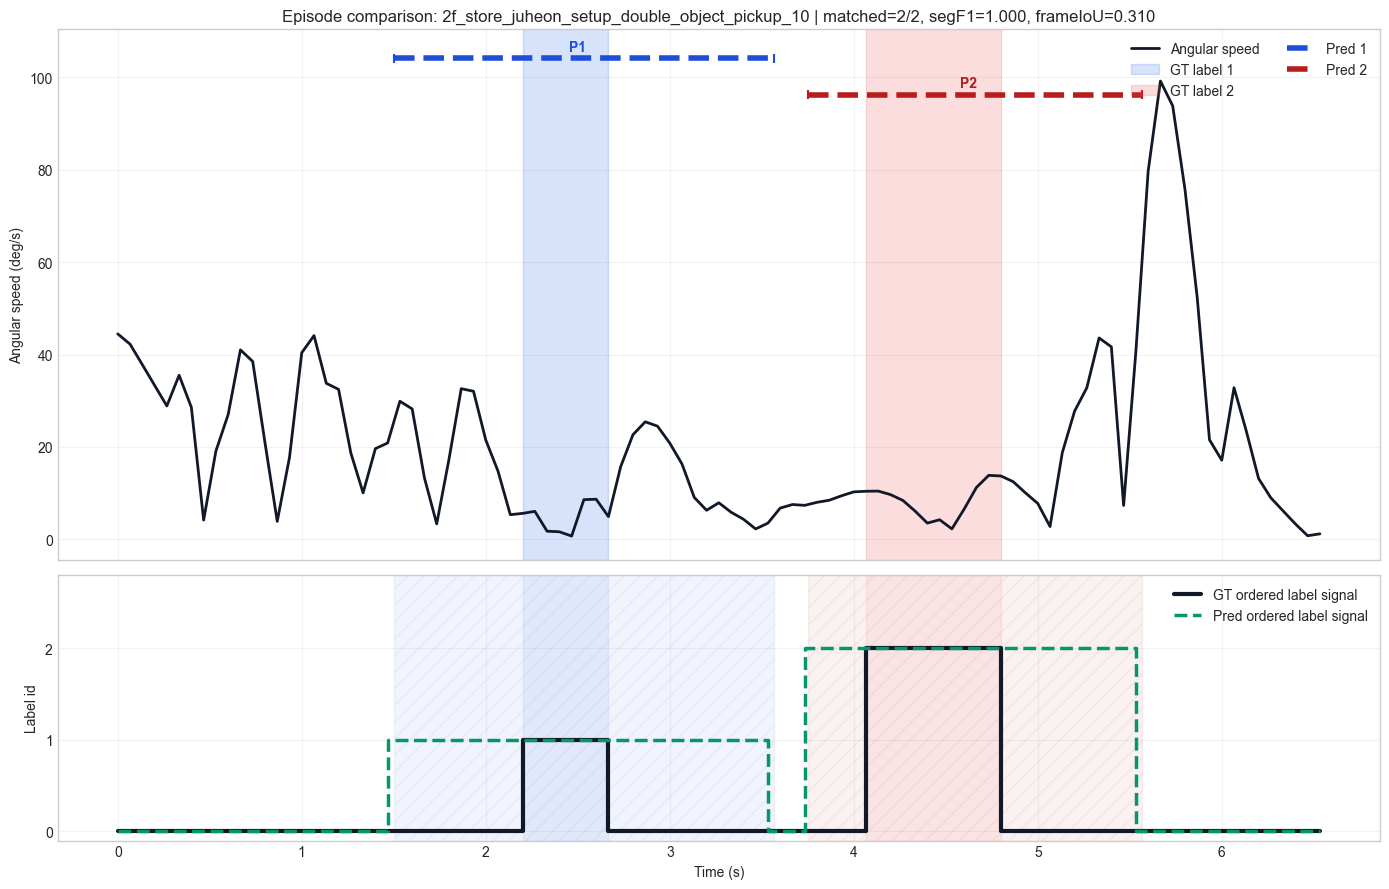

In [47]:
frame_times = episode_data["frame_times"]
gt_signal = episode_data["ordered_label_signal"]
angular_speed = episode_data["angular_speed_deg_s"]

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True, gridspec_kw={"height_ratios": [3, 1.5]})
speed_ax, signal_ax = axes

if np.all(np.isnan(angular_speed)):
    speed_ax.text(0.5, 0.5, "No gaze data available", ha="center", va="center", transform=speed_ax.transAxes)
else:
    speed_ax.plot(frame_times, angular_speed, color="#111827", linewidth=2.0, label="Angular speed")

for segment in episode_data["segments"]:
    label_id = int(segment["label_id"])
    color = GT_COLORS.get(label_id, plt.cm.tab10((label_id - 1) % 10))
    speed_ax.axvspan(
        segment["start_sec"],
        segment["end_sec"] + episode_data["frame_step_sec"],
        color=color,
        alpha=0.18,
        label=f"GT label {label_id}",
    )

speed_max = float(np.nanmax(angular_speed)) if not np.all(np.isnan(angular_speed)) else 1.0
pred_base = max(speed_max * 1.05, 5.0)
pred_gap = max(speed_max * 0.08, 2.0)
for interval in prediction_intervals:
    label_id = int(interval["pred_idx"]) + 1
    color = PRED_COLORS.get(label_id, plt.cm.tab10((label_id - 1) % 10))
    y_level = pred_base - pred_gap * interval["pred_idx"]
    speed_ax.hlines(
        y=y_level,
        xmin=interval["start_sec"],
        xmax=interval["end_sec"] + episode_data["frame_step_sec"],
        colors=color,
        linewidth=4,
        linestyles="--",
        label=f"Pred {label_id}",
    )
    speed_ax.vlines(
        [interval["start_sec"], interval["end_sec"] + episode_data["frame_step_sec"]],
        y_level - 1.0,
        y_level + 1.0,
        colors=color,
        linewidth=1.5,
    )
    speed_ax.text(
        (interval["start_sec"] + interval["end_sec"]) / 2.0,
        y_level + 1.0,
        f"P{label_id}",
        color=color,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

legend_items = OrderedDict()
for handle, label in zip(*speed_ax.get_legend_handles_labels()):
    legend_items.setdefault(label, handle)
speed_ax.legend(legend_items.values(), legend_items.keys(), loc="upper right", ncol=2)

metric_suffix = ""
if metrics:
    metric_suffix = (
        f" | matched={metrics.get('matched_count', 0)}/{metrics.get('gt_interval_count', 0)}"
        f", segF1={metrics.get('segment_f1', float('nan')):.3f}"
        f", frameIoU={metrics.get('frame_iou', float('nan')):.3f}"
    )
speed_ax.set_title(f"Episode comparison: {EPISODE_NAME}{metric_suffix}")
speed_ax.set_ylabel("Angular speed (deg/s)")
speed_ax.grid(alpha=0.25)

signal_ax.step(frame_times, gt_signal, where="post", linewidth=3.0, color="#111827", label="GT ordered label signal")
signal_ax.step(frame_times, predicted_signal, where="post", linewidth=2.5, linestyle="--", color="#059669", label="Pred ordered label signal")

for segment in episode_data["segments"]:
    label_id = int(segment["label_id"])
    color = GT_COLORS.get(label_id, plt.cm.tab10((label_id - 1) % 10))
    signal_ax.axvspan(
        segment["start_sec"],
        segment["end_sec"] + episode_data["frame_step_sec"],
        color=color,
        alpha=0.08,
    )

for interval in prediction_intervals:
    label_id = int(interval["pred_idx"]) + 1
    color = PRED_COLORS.get(label_id, plt.cm.tab10((label_id - 1) % 10))
    signal_ax.axvspan(
        interval["start_sec"],
        interval["end_sec"] + episode_data["frame_step_sec"],
        facecolor=color,
        alpha=0.06,
        hatch="//",
        edgecolor=color,
    )

max_signal = int(max(gt_signal.max(initial=0), predicted_signal.max(initial=0), 2))
signal_ax.set_ylim(-0.1, max_signal + 0.8)
signal_ax.set_yticks(range(0, max_signal + 1))
signal_ax.set_ylabel("Label id")
signal_ax.set_xlabel("Time (s)")
signal_ax.legend(loc="upper right")
signal_ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


In [48]:
clip_df = build_clip_specs(episode_data, prediction_intervals)
clip_table = clip_df[[
    "kind",
    "label_id",
    "start_frame",
    "end_frame",
    "start_sec",
    "end_sec",
    "duration_sec",
    "clip_start_sec",
    "clip_end_sec",
    "clip_path",
]].copy()
clip_table["clip_path"] = clip_table["clip_path"].astype(str)
display(clip_table.round(4))


,kind,label_id,start_frame,end_frame,start_sec,end_sec,duration_sec,clip_start_sec,clip_end_sec,clip_path
0,gt,1,33,39,2.2000,2.6667,0.4667,1.8000,3.0667,debug/generated_multiseg_clips/2f_store_juheon...
1,gt,2,61,71,4.0667,4.8000,0.7333,3.6667,5.2000,debug/generated_multiseg_clips/2f_store_juheon...
2,pred,1,22,52,1.5000,3.5667,2.0000,1.1000,3.9667,debug/generated_multiseg_clips/2f_store_juheon...
3,pred,2,56,82,3.7500,5.5667,1.7500,3.3500,5.9667,debug/generated_multiseg_clips/2f_store_juheon...


In [49]:
for _, row in clip_df.iterrows():
    title = (
        f"{row['kind'].upper()} label {int(row['label_id'])} | "
        f"segment={row['start_sec']:.2f}-{row['end_sec']:.2f}s | "
        f"clip={row['clip_start_sec']:.2f}-{row['clip_end_sec']:.2f}s"
    )
    print(title)
    display(Video(str(row["clip_path"]), embed=False, html_attributes="controls"))


GT label 1 | segment=2.20-2.67s | clip=1.80-3.07s


GT label 2 | segment=4.07-4.80s | clip=3.67-5.20s


PRED label 1 | segment=1.50-3.57s | clip=1.10-3.97s


PRED label 2 | segment=3.75-5.57s | clip=3.35-5.97s


In [50]:
MIDPOINT_MARKER_COLOR = "#f59e0b"
MIN_VEL_MARKER_COLOR = "#0f766e"


def list_prediction_sources() -> list[Path]:
    candidate_paths = []
    candidate_paths.extend(sorted(Path("eval_results_multiseg").glob("*_results.jsonl")))
    candidate_paths.extend(sorted(Path("results").glob("result_multiseg_*.json")))
    return [path for path in candidate_paths if path.exists()]


def list_refinement_sources() -> list[Path]:
    return sorted(Path("results").glob("refined_result_multiseg_*.json"))


prediction_record_cache: dict[str, list[dict]] = {}
refinement_payload_cache: dict[str, dict] = {}
refinement_episode_lookup_cache: dict[str, dict[str, dict]] = {}


def get_prediction_records_cached(source_path: Path) -> list[dict]:
    cache_key = str(source_path)
    if cache_key not in prediction_record_cache:
        prediction_record_cache[cache_key] = load_prediction_records(source_path)
    return prediction_record_cache[cache_key]


def load_refinement_payload(source_path: Path) -> dict:
    if not source_path.exists():
        raise FileNotFoundError(f"Refinement source not found: {source_path}")
    payload = json.loads(source_path.read_text())
    if not isinstance(payload, dict) or not isinstance(payload.get("episodes"), list):
        raise ValueError(f"Unsupported refinement payload: {source_path}")
    return payload


def get_refinement_payload_cached(source_path: Path) -> dict:
    cache_key = str(source_path)
    if cache_key not in refinement_payload_cache:
        refinement_payload_cache[cache_key] = load_refinement_payload(source_path)
    return refinement_payload_cache[cache_key]


def get_refinement_episode_lookup(source_path: Path) -> dict[str, dict]:
    cache_key = str(source_path)
    if cache_key not in refinement_episode_lookup_cache:
        payload = get_refinement_payload_cached(source_path)
        refinement_episode_lookup_cache[cache_key] = {
            episode["episode"]: episode
            for episode in payload.get("episodes", [])
            if isinstance(episode, dict) and episode.get("episode")
        }
    return refinement_episode_lookup_cache[cache_key]


def get_available_episode_names(source_path: Path) -> list[str]:
    episodes = []
    for record in get_prediction_records_cached(source_path):
        episode = record.get("episode")
        if not episode:
            continue
        if (DATASET_DIR / episode).exists():
            episodes.append(episode)
    return sorted(dict.fromkeys(episodes))


def extract_source_signature(source_path: Path) -> dict | None:
    if source_path.suffix == ".json":
        try:
            payload = json.loads(source_path.read_text())
        except Exception:
            payload = None
        if isinstance(payload, dict):
            if source_path.name.startswith("refined_result_multiseg_"):
                config = payload.get("vlm_config") or {}
                if config:
                    return {
                        "model": config.get("model"),
                        "video_fps": int(config.get("video_fps")) if config.get("video_fps") is not None else None,
                        "max_intervals": int(config.get("max_intervals")) if config.get("max_intervals") is not None else None,
                        "gaze_annot": bool(config.get("gaze_annot")) if config.get("gaze_annot") is not None else None,
                        "caption": bool(config.get("caption")) if config.get("caption") is not None else None,
                    }
            config = payload.get("config") or {}
            if config and source_path.name.startswith("result_multiseg_"):
                return {
                    "model": config.get("model"),
                    "video_fps": int(config.get("video_fps")) if config.get("video_fps") is not None else None,
                    "max_intervals": int(config.get("max_intervals")) if config.get("max_intervals") is not None else None,
                    "gaze_annot": bool(config.get("gaze_annot")) if config.get("gaze_annot") is not None else None,
                    "caption": bool(config.get("caption")) if config.get("caption") is not None else None,
                }

    match = re.match(
        r"^multiseg_(?P<model>.+)_fps(?P<fps>\d+)_max(?P<max_intervals>\d+)(?P<flags>(?:_(?:cap|gaze))*)_results$",
        source_path.stem,
    )
    if match:
        flags = set(token for token in match.group("flags").split("_") if token)
        return {
            "model": match.group("model"),
            "video_fps": int(match.group("fps")),
            "max_intervals": int(match.group("max_intervals")),
            "gaze_annot": "gaze" in flags,
            "caption": "cap" in flags,
        }

    match = re.match(
        r"^(?:refined_)?result_multiseg_(?P<model>.+?)_gaze_(?P<gaze>true|false)_cap_(?P<cap>true|false)_fps(?P<fps>\d+)_max(?P<max_intervals>\d+)$",
        source_path.stem,
    )
    if match:
        return {
            "model": match.group("model"),
            "video_fps": int(match.group("fps")),
            "max_intervals": int(match.group("max_intervals")),
            "gaze_annot": match.group("gaze") == "true",
            "caption": match.group("cap") == "true",
        }

    return None


def auto_resolve_refinement_source(source_path: Path) -> Path | None:
    exact_candidate = source_path.with_name(f"refined_{source_path.name}")
    if exact_candidate.exists():
        return exact_candidate

    source_sig = extract_source_signature(source_path)
    if source_sig is None:
        return None

    candidates = []
    for refinement_path in list_refinement_sources():
        refinement_sig = extract_source_signature(refinement_path)
        if refinement_sig is None:
            continue
        if refinement_sig.get("model") != source_sig.get("model"):
            continue
        if refinement_sig.get("video_fps") != source_sig.get("video_fps"):
            continue
        if refinement_sig.get("max_intervals") != source_sig.get("max_intervals"):
            continue

        compatible = True
        for flag_key in ("gaze_annot", "caption"):
            source_flag = source_sig.get(flag_key)
            refinement_flag = refinement_sig.get(flag_key)
            if source_flag is not None and refinement_flag is not None and source_flag != refinement_flag:
                compatible = False
                break
        if compatible:
            candidates.append(refinement_path)

    if len(candidates) == 1:
        return candidates[0]
    if candidates:
        return sorted(candidates)[0]
    return None


def build_refinement_frame_df(refinement_episode: dict, fps: float) -> pd.DataFrame:
    rows = []
    for interval_result in refinement_episode.get("intervals", []):
        midpoint = interval_result.get("midpoint") or {}
        gaze_velocity = interval_result.get("gaze_velocity") or {}
        start_frame, end_frame = interval_result.get("vlm_interval_frames", [None, None])
        gt_frames = interval_result.get("matched_gt_interval_frames", [None, None])

        row = {
            "interval_idx": interval_result.get("interval_idx"),
            "pred_start_frame": start_frame,
            "pred_end_frame": end_frame,
            "pred_start_sec": round(start_frame / fps, 4) if start_frame is not None else np.nan,
            "pred_end_sec": round(end_frame / fps, 4) if end_frame is not None else np.nan,
            "midpoint_frame": midpoint.get("selected_frame"),
            "midpoint_sec": round(midpoint.get("selected_frame", 0) / fps, 4) if midpoint.get("selected_frame") is not None else np.nan,
            "midpoint_hit": midpoint.get("hit"),
            "midpoint_nearest_gt_dist": midpoint.get("nearest_gt_dist"),
            "min_velocity_frame": gaze_velocity.get("selected_frame"),
            "min_velocity_sec": round(gaze_velocity.get("selected_frame", 0) / fps, 4) if gaze_velocity.get("selected_frame") is not None else np.nan,
            "min_velocity_hit": gaze_velocity.get("hit"),
            "min_velocity_nearest_gt_dist": gaze_velocity.get("nearest_gt_dist"),
            "min_velocity_deg_s": gaze_velocity.get("velocity_deg_s"),
            "matched_gt_start_frame": gt_frames[0],
            "matched_gt_end_frame": gt_frames[1],
            "matched_gt_start_sec": round(gt_frames[0] / fps, 4) if gt_frames[0] is not None else np.nan,
            "matched_gt_end_sec": round(gt_frames[1] / fps, 4) if gt_frames[1] is not None else np.nan,
        }
        rows.append(row)
    return pd.DataFrame(rows)


def render_episode_comparison(source_path: Path, episode_name: str, refinement_source: Path | None = None) -> None:
    prediction_records = get_prediction_records_cached(source_path)
    selected_record = next((record for record in prediction_records if record.get("episode") == episode_name), None)
    if selected_record is None:
        raise ValueError(f"Episode not found in prediction source: {episode_name}")

    episode_data = load_episode_data(DATASET_DIR / episode_name)
    prediction = selected_record.get("prediction") or {"reasoning": "", "intervals": []}
    prediction_intervals = normalize_prediction_intervals(prediction.get("intervals", []), episode_data["fps"])
    predicted_signal = build_interval_signal(episode_data["total_frames"], prediction_intervals, id_key="pred_idx")

    metrics = selected_record.get("metrics") or {}
    matches = selected_record.get("matches") or []
    reasoning = prediction.get("reasoning", "")

    refinement_episode = None
    refinement_df = pd.DataFrame()
    refinement_summary = {}
    if refinement_source is not None and refinement_source.exists():
        refinement_lookup = get_refinement_episode_lookup(refinement_source)
        refinement_episode = refinement_lookup.get(episode_name)
        if refinement_episode is not None:
            refinement_df = build_refinement_frame_df(refinement_episode, episode_data["fps"])
            refinement_summary = refinement_episode.get("episode_summary") or {}

    print(f"Prediction source: {source_path}")
    print(f"Selected episode: {episode_name}")
    print(
        f"FPS: {episode_data['fps']:.2f}, total frames: {episode_data['total_frames']}, "
        f"duration: {episode_data['duration_sec']:.2f}s"
    )
    if refinement_source is not None:
        print(f"Refinement source: {refinement_source}")
        if refinement_summary:
            print(
                "Representative-frame hits: "
                f"midpoint={refinement_summary.get('midpoint_hit_count', 0)}/"
                f"{refinement_summary.get('pred_interval_count', 0)}, "
                f"min-velocity={refinement_summary.get('gaze_velocity_hit_count', 0)}/"
                f"{refinement_summary.get('pred_interval_count', 0)}"
            )
        elif refinement_episode is None:
            print("Representative-frame data: this episode is not present in the selected refinement file.")

    gt_df = pd.DataFrame(episode_data["segments"])
    pred_df = pd.DataFrame(prediction_intervals)
    metric_df = pd.DataFrame([metrics]).T.rename(columns={0: "value"}) if metrics else pd.DataFrame()
    match_df = pd.DataFrame(matches)

    display(gt_df.round(4))
    display(pred_df.round(4))
    if not metric_df.empty:
        display(metric_df)
    if not match_df.empty:
        display(match_df)
    if not refinement_df.empty:
        display(refinement_df.round(4))
    if reasoning:
        print("Reasoning:")
        print(reasoning)

    frame_times = episode_data["frame_times"]
    gt_signal = episode_data["ordered_label_signal"]
    angular_speed = episode_data["angular_speed_deg_s"]

    fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True, gridspec_kw={"height_ratios": [3, 1.5]})
    speed_ax, signal_ax = axes

    if np.all(np.isnan(angular_speed)):
        speed_ax.text(0.5, 0.5, "No gaze data available", ha="center", va="center", transform=speed_ax.transAxes)
    else:
        speed_ax.plot(frame_times, angular_speed, color="#111827", linewidth=2.0, label="Angular speed")

    for segment in episode_data["segments"]:
        label_id = int(segment["label_id"])
        color = GT_COLORS.get(label_id, plt.cm.tab10((label_id - 1) % 10))
        speed_ax.axvspan(
            segment["start_sec"],
            segment["end_sec"] + episode_data["frame_step_sec"],
            color=color,
            alpha=0.18,
            label=f"GT label {label_id}",
        )

    speed_max = float(np.nanmax(angular_speed)) if not np.all(np.isnan(angular_speed)) else 1.0
    pred_base = max(speed_max * 1.05, 5.0)
    pred_gap = max(speed_max * 0.08, 2.0)
    for interval in prediction_intervals:
        label_id = int(interval["pred_idx"]) + 1
        color = PRED_COLORS.get(label_id, plt.cm.tab10((label_id - 1) % 10))
        y_level = pred_base - pred_gap * interval["pred_idx"]
        speed_ax.hlines(
            y=y_level,
            xmin=interval["start_sec"],
            xmax=interval["end_sec"] + episode_data["frame_step_sec"],
            colors=color,
            linewidth=4,
            linestyles="--",
            label=f"Pred {label_id}",
        )
        speed_ax.vlines(
            [interval["start_sec"], interval["end_sec"] + episode_data["frame_step_sec"]],
            y_level - 1.0,
            y_level + 1.0,
            colors=color,
            linewidth=1.5,
        )
        speed_ax.text(
            (interval["start_sec"] + interval["end_sec"]) / 2.0,
            y_level + 1.0,
            f"P{label_id}",
            color=color,
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

    if not refinement_df.empty:
        midpoint_label_drawn = False
        min_vel_label_drawn = False
        label_offset = max(speed_max * 0.03, 1.25)

        for _, row in refinement_df.iterrows():
            label_id = int(row["interval_idx"]) + 1

            midpoint_frame = row.get("midpoint_frame")
            if pd.notna(midpoint_frame):
                midpoint_frame = int(midpoint_frame)
                midpoint_sec = float(row["midpoint_sec"])
                midpoint_y = pred_base + pred_gap
                if 0 <= midpoint_frame < len(angular_speed) and not np.isnan(angular_speed[midpoint_frame]):
                    midpoint_y = float(angular_speed[midpoint_frame])
                speed_ax.axvline(midpoint_sec, color=MIDPOINT_MARKER_COLOR, linestyle=":", linewidth=1.3, alpha=0.55)
                speed_ax.scatter(
                    midpoint_sec,
                    midpoint_y,
                    s=90,
                    marker="o",
                    color=MIDPOINT_MARKER_COLOR,
                    edgecolors="white",
                    linewidth=1.1,
                    zorder=5,
                    label="Midpoint frame" if not midpoint_label_drawn else None,
                )
                speed_ax.text(
                    midpoint_sec,
                    midpoint_y + label_offset,
                    f"M{label_id}",
                    color=MIDPOINT_MARKER_COLOR,
                    ha="center",
                    va="bottom",
                    fontsize=9,
                    fontweight="bold",
                )
                signal_ax.axvline(
                    midpoint_sec,
                    color=MIDPOINT_MARKER_COLOR,
                    linestyle=":",
                    linewidth=1.4,
                    alpha=0.85,
                )
                midpoint_label_drawn = True

            min_velocity_frame = row.get("min_velocity_frame")
            if pd.notna(min_velocity_frame):
                min_velocity_frame = int(min_velocity_frame)
                min_velocity_sec = float(row["min_velocity_sec"])
                min_velocity_y = pred_base + pred_gap * 1.6
                if 0 <= min_velocity_frame < len(angular_speed) and not np.isnan(angular_speed[min_velocity_frame]):
                    min_velocity_y = float(angular_speed[min_velocity_frame])
                speed_ax.axvline(min_velocity_sec, color=MIN_VEL_MARKER_COLOR, linestyle="-.", linewidth=1.3, alpha=0.55)
                speed_ax.scatter(
                    min_velocity_sec,
                    min_velocity_y,
                    s=95,
                    marker="D",
                    color=MIN_VEL_MARKER_COLOR,
                    edgecolors="white",
                    linewidth=1.1,
                    zorder=5,
                    label="Min gaze-speed frame" if not min_vel_label_drawn else None,
                )
                speed_ax.text(
                    min_velocity_sec,
                    min_velocity_y + label_offset,
                    f"G{label_id}",
                    color=MIN_VEL_MARKER_COLOR,
                    ha="center",
                    va="bottom",
                    fontsize=9,
                    fontweight="bold",
                )
                signal_ax.axvline(
                    min_velocity_sec,
                    color=MIN_VEL_MARKER_COLOR,
                    linestyle="-.",
                    linewidth=1.4,
                    alpha=0.85,
                )
                min_vel_label_drawn = True

    legend_items = OrderedDict()
    for handle, label in zip(*speed_ax.get_legend_handles_labels()):
        legend_items.setdefault(label, handle)
    speed_ax.legend(legend_items.values(), legend_items.keys(), loc="upper right", ncol=2)

    metric_suffix = ""
    if metrics:
        metric_suffix = (
            f" | matched={metrics.get('matched_count', 0)}/{metrics.get('gt_interval_count', 0)}"
            f", segF1={metrics.get('segment_f1', float('nan')):.3f}"
            f", frameIoU={metrics.get('frame_iou', float('nan')):.3f}"
        )
    speed_ax.set_title(f"Episode comparison: {episode_name}{metric_suffix}")
    speed_ax.set_ylabel("Angular speed (deg/s)")
    speed_ax.grid(alpha=0.25)

    signal_ax.step(frame_times, gt_signal, where="post", linewidth=3.0, color="#111827", label="GT ordered label signal")
    signal_ax.step(frame_times, predicted_signal, where="post", linewidth=2.5, linestyle="--", color="#059669", label="Pred ordered label signal")

    for segment in episode_data["segments"]:
        label_id = int(segment["label_id"])
        color = GT_COLORS.get(label_id, plt.cm.tab10((label_id - 1) % 10))
        signal_ax.axvspan(
            segment["start_sec"],
            segment["end_sec"] + episode_data["frame_step_sec"],
            color=color,
            alpha=0.08,
        )

    for interval in prediction_intervals:
        label_id = int(interval["pred_idx"]) + 1
        color = PRED_COLORS.get(label_id, plt.cm.tab10((label_id - 1) % 10))
        signal_ax.axvspan(
            interval["start_sec"],
            interval["end_sec"] + episode_data["frame_step_sec"],
            facecolor=color,
            alpha=0.06,
            hatch="//",
            edgecolor=color,
        )

    max_signal = int(max(gt_signal.max(initial=0), predicted_signal.max(initial=0), 2))
    signal_ax.set_ylim(-0.1, max_signal + 0.8)
    signal_ax.set_yticks(range(0, max_signal + 1))
    signal_ax.set_ylabel("Label id")
    signal_ax.set_xlabel("Time (s)")
    signal_ax.legend(loc="upper right")
    signal_ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    clip_df = build_clip_specs(episode_data, prediction_intervals)
    clip_table = clip_df[[
        "kind",
        "label_id",
        "start_frame",
        "end_frame",
        "start_sec",
        "end_sec",
        "duration_sec",
        "clip_start_sec",
        "clip_end_sec",
        "clip_path",
    ]].copy()
    clip_table["clip_path"] = clip_table["clip_path"].astype(str)
    display(clip_table.round(4))

    for _, row in clip_df.iterrows():
        title = (
            f"{row['kind'].upper()} label {int(row['label_id'])} | "
            f"segment={row['start_sec']:.2f}-{row['end_sec']:.2f}s | "
            f"clip={row['clip_start_sec']:.2f}-{row['clip_end_sec']:.2f}s"
        )
        print(title)
        display(Video(str(row["clip_path"]), embed=False, html_attributes="controls"))


In [ ]:
prediction_sources = list_prediction_sources()
if not prediction_sources:
    raise ValueError("No supported multi-segment result files found under eval_results_multiseg/ or results/.")

refinement_sources = list_refinement_sources()

source_options = [(str(path), str(path)) for path in prediction_sources]
default_source = str(PREDICTION_SOURCE) if PREDICTION_SOURCE.exists() and PREDICTION_SOURCE in prediction_sources else source_options[0][1]

source_selector = widgets.Dropdown(
    options=source_options,
    value=default_source,
    description="Result file",
    layout=widgets.Layout(width="900px"),
    style={"description_width": "90px"},
)

refinement_options = [("Auto", "__AUTO__"), ("None", "__NONE__")]
refinement_options.extend((str(path), str(path)) for path in refinement_sources)
refinement_selector = widgets.Dropdown(
    options=refinement_options,
    value="__AUTO__",
    description="Refinement",
    layout=widgets.Layout(width="900px"),
    style={"description_width": "90px"},
)

episode_selector = widgets.Select(
    options=[],
    description="Episode",
    rows=12,
    layout=widgets.Layout(width="900px", height="280px"),
    style={"description_width": "90px"},
)

status_html = widgets.HTML()
output = widgets.Output()


def resolve_selected_refinement_source() -> Path | None:
    selected_value = refinement_selector.value
    if selected_value == "__NONE__":
        return None
    if selected_value == "__AUTO__":
        return auto_resolve_refinement_source(Path(source_selector.value))
    return Path(selected_value)


def update_status_html() -> None:
    source_path = Path(source_selector.value)
    total_records = len(get_prediction_records_cached(source_path))
    visible_episodes = len(episode_selector.options)
    refinement_path = resolve_selected_refinement_source()

    parts = [
        f"<b>{source_path}</b>",
        f"{visible_episodes} comparable episode(s) with dataset folders, {total_records} record(s) in this result file.",
    ]
    if refinement_path is not None:
        refinement_lookup = get_refinement_episode_lookup(refinement_path)
        parts.append(
            f"Refinement markers: <code>{refinement_path}</code> "
            f"({len(refinement_lookup)} episode(s) with midpoint / min-gaze-speed picks)."
        )
    else:
        parts.append("Refinement markers: disabled.")
    status_html.value = "<br>".join(parts)


def update_episode_selector(change=None) -> None:
    source_path = Path(source_selector.value)
    episodes = get_available_episode_names(source_path)
    previous_value = episode_selector.value
    episode_selector.options = episodes
    update_status_html()

    if not episodes:
        with output:
            clear_output(wait=True)
            print("No comparable episodes found for this result file.")
        return

    if change is None and source_path == PREDICTION_SOURCE and EPISODE_NAME in episodes:
        target_episode = EPISODE_NAME
    elif previous_value in episodes:
        target_episode = previous_value
    else:
        target_episode = episodes[0]

    if episode_selector.value != target_episode:
        episode_selector.value = target_episode
    else:
        render_current_episode()


def render_current_episode(change=None) -> None:
    if not episode_selector.value:
        return

    refinement_path = resolve_selected_refinement_source()
    update_status_html()

    with output:
        clear_output(wait=True)
        render_episode_comparison(
            Path(source_selector.value),
            episode_selector.value,
            refinement_source=refinement_path,
        )


source_selector.observe(update_episode_selector, names="value")
refinement_selector.observe(render_current_episode, names="value")
episode_selector.observe(render_current_episode, names="value")

update_episode_selector()

display(
    widgets.VBox(
        [
            widgets.HTML(
                "<h3>Interactive episode browser</h3>"
                "<p>Pick a multi-segment result file, then click an episode to refresh the comparison below. "
                "If a refinement file is available, amber circles mark interval midpoints and teal diamonds mark "
                "the minimum gaze-speed frame inside each predicted interval.</p>"
            ),
            source_selector,
            refinement_selector,
            status_html,
            episode_selector,
            output,
        ]
    )
)
